In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("./data/buy_dualoptions.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'ID', 'InvestCoin', 'ExercisedCoin', 'StrikePrice',
       'Duration', 'APR', 'OrderId', 'OptionType', 'Curr_price',
       'Percent_to_strikeprice', 'PremiumReceived(USD)', 'date', 'date_new',
       'strikeprice_weighted'],
      dtype='object')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load Data (Assuming it's in a CSV)
df = pd.read_csv("./data/sell_dualoptions.csv")

# Convert Date Format
df['date'] = pd.to_datetime(df['date'], format="%d%m%y:%H")

# Ensure Numeric Columns
numeric_cols = ['StrikePrice', 'Duration', 'APR', 'Curr_price', 'Percent_to_strikeprice', 'PremiumReceived(USD)']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Sort by Date
df = df.sort_values(by="date")

In [10]:
# Compute Historical Volatility (Rolling Std Dev of Returns)
df['log_return'] = np.log(df['Curr_price'] / df['Curr_price'].shift(1))
df['volatility_7d'] = df['log_return'].rolling(window=7, min_periods=1).std() * np.sqrt(365)

# Compute Moneyness Feature (Relative Distance to Strike)
df['moneyness'] = df['Curr_price'] / df['StrikePrice']

# Rolling Moving Averages
df['SMA_3'] = df['Curr_price'].rolling(window=3).mean()
df['SMA_7'] = df['Curr_price'].rolling(window=7).mean()

# Compute Implied Probability (Using Simple Approximation)
df['implied_prob'] = np.exp(-df['Percent_to_strikeprice'])  # Rough proxy, can refine later

# Encode Option Type (Call = 1, Put = 0)
df['OptionType_Encoded'] = df['OptionType'].map({'CALL': 1, 'PUT': 0})

# Drop NaNs (from rolling calculations)
df.dropna(inplace=True)

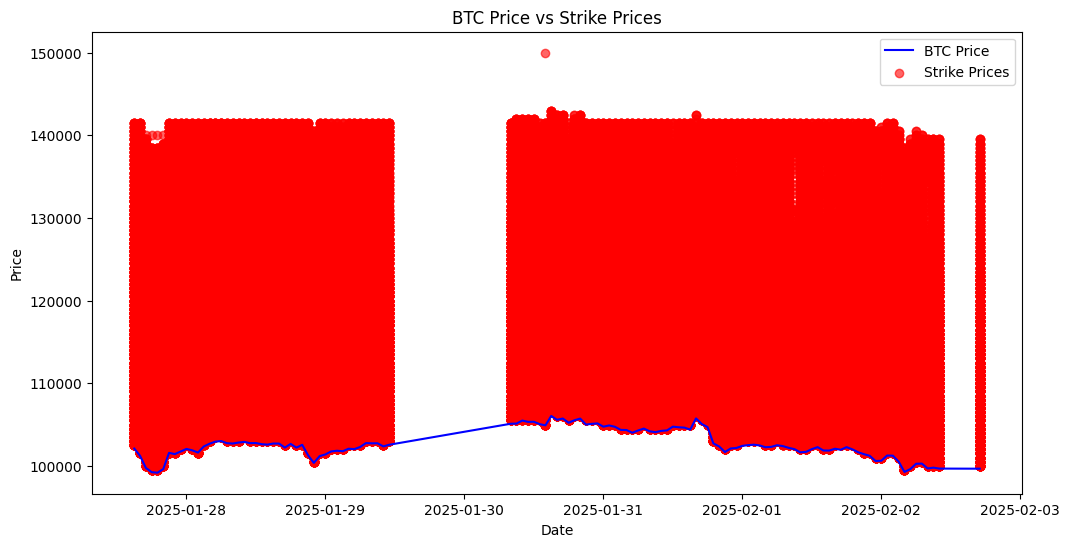

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['Curr_price'], label='BTC Price', color='blue')
plt.scatter(df['date'], df['StrikePrice'], label='Strike Prices', color='red', alpha=0.6)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('BTC Price vs Strike Prices')
plt.legend()
plt.show()

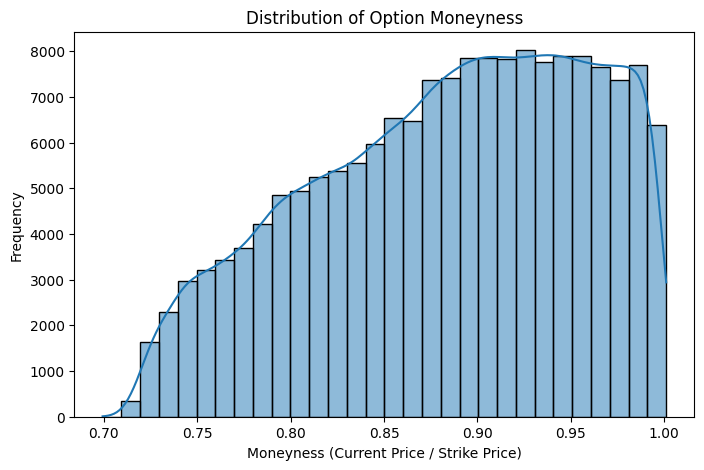

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['moneyness'], bins=30, kde=True)
plt.xlabel("Moneyness (Current Price / Strike Price)")
plt.ylabel("Frequency")
plt.title("Distribution of Option Moneyness")
plt.show()

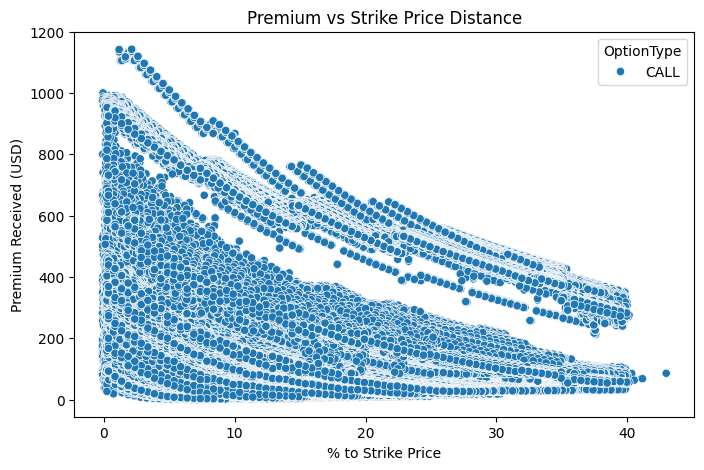

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Percent_to_strikeprice'], y=df['PremiumReceived(USD)'], hue=df['OptionType'])
plt.xlabel("% to Strike Price")
plt.ylabel("Premium Received (USD)")
plt.title("Premium vs Strike Price Distance")
plt.show()

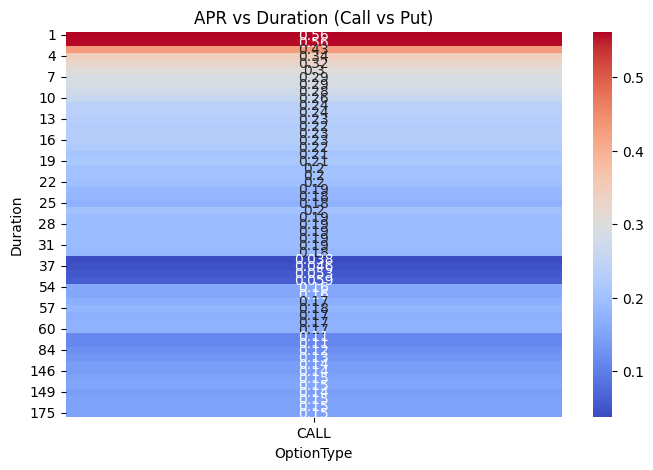

In [14]:
plt.figure(figsize=(8, 5))
pivot_table = df.pivot_table(values='APR', index='Duration', columns='OptionType', aggfunc='mean')
sns.heatmap(pivot_table, cmap='coolwarm', annot=True)
plt.title("APR vs Duration (Call vs Put)")
plt.show()

In [15]:
# Create a column to track if the strike price was hit within the duration
df['expiry_price'] = df.groupby('ID')['Curr_price'].shift(-df['Duration'])  # Price at expiry
df['strike_hit'] = (df['expiry_price'] >= df['StrikePrice']).astype(int)  # 1 if hit, 0 otherwise

# Drop NaNs (due to shift operation)
df.dropna(inplace=True)

# Check probabilities
print(df['strike_hit'].value_counts(normalize=True))

: 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Select Features
features = ['Percent_to_strikeprice', 'Duration', 'volatility_7d', 'moneyness', 'APR']
X = df[features]
y = df['strike_hit']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# Evaluate Model
y_pred = log_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate Model
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

In [ ]:
def monte_carlo_simulation(S0, mu, sigma, T, N=1000):
    dt = 1  # Daily steps
    simulations = []
    
    for _ in range(N):
        price_path = [S0]
        for _ in range(T):
            dS = mu * price_path[-1] * dt + sigma * price_path[-1] * np.random.normal()
            price_path.append(price_path[-1] + dS)
        simulations.append(price_path[-1])
    
    return np.array(simulations)

# Run Simulation
df['monte_carlo_prob'] = df.apply(lambda row: (monte_carlo_simulation(
    row['Curr_price'], 0.05, row['volatility_7d'], row['Duration']) >= row['StrikePrice']).mean(), axis=1)

# Compare Model Predictions vs Monte Carlo
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Percent_to_strikeprice'], y=df['monte_carlo_prob'])
plt.xlabel("% to Strike Price")
plt.ylabel("Simulated Probability")
plt.title("Monte Carlo vs % to Strike Price")
plt.show()